In [1]:
import os, random, numpy as np
SEED = 23
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
random.seed(SEED)
np.random.seed(SEED)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import os

In [8]:
import pandas as pd

# Your list of adata objects
adatas = [
    adata_065_314, adata_074_314, adata_096_314, adata_097_314,
    adata_099_314, adata_104_314, adata_106_314, adata_107_314,  
    adata_065_480, adata_074_480, adata_096_480, adata_097_480,
    adata_099_480, adata_104_480, adata_106_480, adata_107_480
]

# Initialize lists to hold counts
dataset_names = [
    "MH065_314", "MH074_314", "MH096_314", "MH097_314",
    "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
    "MH065_480", "MH074_480","MH096_480", "MH097_480",
    "MH099_480", "MH104_480", "MH106_480", "MH107_480"
]
tuft_counts = []
total_counts = []
tuft_percentages = []

for adata, name in zip(adatas, dataset_names):
    # Count number of tuft cells
    tuft_count = (adata.obs["cell_class_threshold"] == "Tuft").sum()
    total_count = adata.shape[0]
    percentage = (tuft_count / total_count) * 100 if total_count > 0 else 0
    
    tuft_counts.append(tuft_count)
    total_counts.append(total_count)
    tuft_percentages.append(percentage)

# Make a summary dataframe
summary_df = pd.DataFrame({
    "Dataset": dataset_names,
    "Tuft Cell Count": tuft_counts,
    "Total Cell Count": total_counts,
    "Tuft Cell %": tuft_percentages
})

# Show combined totals
combined_tuft_count = sum(tuft_counts)
combined_total_count = sum(total_counts)
combined_percentage = (combined_tuft_count / combined_total_count) * 100 if combined_total_count > 0 else 0

# Add combined summary row
combined_summary = pd.DataFrame({
    "Dataset": ["Combined"],
    "Tuft Cell Count": [combined_tuft_count],
    "Total Cell Count": [combined_total_count],
    "Tuft Cell %": [combined_percentage]
})

# Final summary
final_summary_df = pd.concat([summary_df, combined_summary], ignore_index=True)

print(final_summary_df)

      Dataset  Tuft Cell Count  Total Cell Count  Tuft Cell %
0   MH065_314               61            154206     0.039557
1   MH074_314             1446            145717     0.992334
2   MH096_314                0            174784     0.000000
3   MH097_314               20            282289     0.007085
4   MH099_314                0            141568     0.000000
5   MH104_314                0            101830     0.000000
6   MH106_314                0            153269     0.000000
7   MH107_314                0             97631     0.000000
8   MH065_480                0             93891     0.000000
9   MH074_480              129            264689     0.048736
10  MH096_480              112            458968     0.024403
11  MH097_480                0            194626     0.000000
12  MH099_480               92            144282     0.063764
13  MH104_480                0            162903     0.000000
14  MH106_480              101            146148     0.069108
15  MH10

In [9]:
# Your list of adata objects - without the rare sample MH074_314
adatas = [
    adata_065_314,  adata_096_314,adata_097_314,
    adata_099_314, adata_104_314, adata_106_314,adata_107_314,  
    adata_065_480, adata_074_480, adata_096_480, adata_097_480,
    adata_099_480, adata_104_480, adata_106_480, adata_107_480
]

# Initialize lists to hold counts
dataset_names = [
    "MH065_314",  "MH096_314", "MH097_314",
    "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
    "MH065_480", "MH074_480","MH096_480", "MH097_480",
    "MH099_480", "MH104_480", "MH106_480", "MH107_480"
]
tuft_counts = []
total_counts = []
tuft_percentages = []

for adata, name in zip(adatas, dataset_names):
    # Count number of tuft cells
    tuft_count = (adata.obs["cell_class_threshold"] == "Tuft").sum()
    total_count = adata.shape[0]
    percentage = (tuft_count / total_count) * 100 if total_count > 0 else 0
    
    tuft_counts.append(tuft_count)
    total_counts.append(total_count)
    tuft_percentages.append(percentage)

# Make a summary dataframe
summary_df = pd.DataFrame({
    "Dataset": dataset_names,
    "Tuft Cell Count": tuft_counts,
    "Total Cell Count": total_counts,
    "Tuft Cell %": tuft_percentages
})

# Show combined totals
combined_tuft_count = sum(tuft_counts)
combined_total_count = sum(total_counts)
combined_percentage = (combined_tuft_count / combined_total_count) * 100 if combined_total_count > 0 else 0

# Add combined summary row
combined_summary = pd.DataFrame({
    "Dataset": ["Combined"],
    "Tuft Cell Count": [combined_tuft_count],
    "Total Cell Count": [combined_total_count],
    "Tuft Cell %": [combined_percentage]
})

# Final summary
final_summary_df = pd.concat([summary_df, combined_summary], ignore_index=True)

print(final_summary_df)

      Dataset  Tuft Cell Count  Total Cell Count  Tuft Cell %
0   MH065_314               61            154206     0.039557
1   MH096_314                0            174784     0.000000
2   MH097_314               20            282289     0.007085
3   MH099_314                0            141568     0.000000
4   MH104_314                0            101830     0.000000
5   MH106_314                0            153269     0.000000
6   MH107_314                0             97631     0.000000
7   MH065_480                0             93891     0.000000
8   MH074_480              129            264689     0.048736
9   MH096_480              112            458968     0.024403
10  MH097_480                0            194626     0.000000
11  MH099_480               92            144282     0.063764
12  MH104_480                0            162903     0.000000
13  MH106_480              101            146148     0.069108
14  MH107_480              161            214226     0.075154
15   Com

In [10]:
# Tuft only dataset n=8 
adata_list = [
    adata_065_314, adata_074_314, adata_097_314,
    adata_074_480, adata_096_480,
    adata_099_480,  adata_106_480, adata_107_480
]

# Initialize lists to hold counts
sample_names = [
    "MH065_314", "MH074_314",  "MH097_314",
    "MH074_480","MH096_480", 
    "MH099_480", "MH106_480", "MH107_480"
]

In [11]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from collections import Counter

def analyze_neighbors_avg_per_cell_type(
    adata,
    radius=50,
    label_key="cell_class_threshold",
    spatial_key="spatial",
    center_label="Tuft",
    exclude_labels=["Unclassified", "Unassigned"]
):
    """
    Analyze neighborhood composition around each tuft cell,
    averaging over all tuft cells in the sample.

    Parameters:
    -----------
    adata : AnnData
        Annotated data matrix with spatial coordinates and cell type labels.
    radius : float
        Radius (in micrometers) to define the neighborhood.
    label_key : str
        Key in adata.obs for cell type labels.
    spatial_key : str
        Key in adata.obsm for spatial coordinates.
    center_label : str
        Cell type to use as center (typically "Malignant").
    exclude_labels : list of str
        Cell types to exclude from neighbor composition.

    Returns:
    --------
    pd.Series
        Average neighborhood composition per malignant cell (as fractions).
    """
    coords = adata.obsm[spatial_key]
    labels = adata.obs[label_key]
    tree = cKDTree(coords)

    indices = np.where(labels == center_label)[0]
    per_cell_compositions = []

    for idx in indices:
        center = coords[idx]
        nearby_idx = tree.query_ball_point(center, r=radius)

        # Exclude self label and other unwanted categories
        neighbor_labels = [
            t for t in labels.iloc[nearby_idx]
            if t not in exclude_labels and t != center_label
        ]

        if neighbor_labels:
            counts = Counter(neighbor_labels)
            total = sum(counts.values())
            composition = {k: v / total for k, v in counts.items()}
            per_cell_compositions.append(composition)

    if not per_cell_compositions:
        return pd.Series(dtype=float)

    avg_df = pd.DataFrame(per_cell_compositions).fillna(0)
    return avg_df.mean()

In [12]:
results_by_sample = {}

# Loop over all samples
for adata, sample_name in zip(adata_list, sample_names):
    print(f"Processing {sample_name}...")

    df = analyze_neighbors_avg_per_cell_type(
        adata=adata,
        center_label="Tuft",
        radius=50,
        label_key="cell_class_threshold",
        spatial_key="spatial"
    )

    results_by_sample[sample_name] = df

Processing MH065_314...
Processing MH074_314...
Processing MH097_314...
Processing MH074_480...
Processing MH096_480...
Processing MH099_480...
Processing MH106_480...
Processing MH107_480...


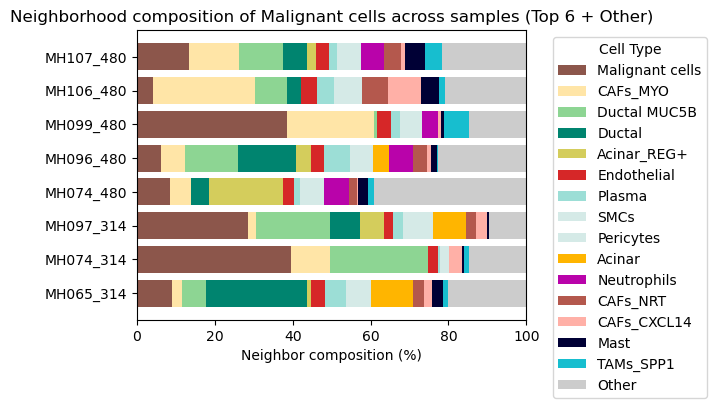

In [13]:
# Extract rows for malignant neighborhood composition
combined = []
for sample_name, series in results_by_sample.items():
    if isinstance(series, pd.Series):
        series.name = sample_name
        combined.append(series)

summary_df = pd.DataFrame(combined).fillna(0)

# Remove 'Unclassified' if present
if "Unclassified" in summary_df.columns:
    summary_df = summary_df.drop(columns=["Unclassified"])

# Find top 15 cell types across all samples
top_cell_types = summary_df.sum().sort_values(ascending=False).head(15).index

# Collapse others into 'Other'
collapsed = summary_df[top_cell_types].copy()
collapsed["Other"] = summary_df.drop(columns=top_cell_types).sum(axis=1)

# Estimate total malignant cells from relative fraction sum
total_cells = {sample: int(row.sum() * 100) for sample, row in summary_df.iterrows()}

manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG+': '#d4cd5c', #'#17becf', #
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "TRCs": '#D8D18C',
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "IPMN": "#525068",
    "Ductal REG+": "#9aa880",
    "Other": "#cccccc"
}

fig, ax = plt.subplots(figsize=(7, 4))
bottom = np.zeros(len(collapsed))
y_pos = np.arange(len(collapsed))

for ct in collapsed.columns:
    values = collapsed[ct].values * 100
    ax.barh(y_pos, values, left=bottom, label=ct, color=manual_colors.get(ct, "#cccccc"))
    bottom += values

# Final plot formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(collapsed.index)
ax.set_xlim(0, 100)
ax.set_xlabel("Neighbor composition (%)")
ax.set_title(f"Neighborhood composition of Malignant cells across samples (Top 6 + Other)")
ax.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
plt.savefig("Tuft_neighbours_bar_top12.pdf")
plt.show()

## Minimum distance profiling 

In [14]:
from scipy.spatial import cKDTree
from collections import defaultdict
import pandas as pd
import numpy as np

all_results = []

for adata, sample_name in zip(adata_list, sample_names):
    coords = adata.obsm['spatial']
    cell_types = adata.obs['cell_class_threshold']
    cell_ids = adata.obs_names

    center_mask = (cell_types == "Tuft")
    center_coords = coords[center_mask.values]
    center_ids = cell_ids[center_mask.values]

    # Only build tree for non Tuft cells
    other_mask = ~center_mask
    other_coords = coords[other_mask.values]
    other_ids = cell_ids[other_mask.values]
    other_types = cell_types[other_mask.values].values

    # Build a cKDTree on non Tuft cells
    tree = cKDTree(other_coords)
    radius_um = 50

    for i, center_coord in enumerate(center_coords):
        center_id = center_ids[i]
        neighbor_idx = tree.query_ball_point(center_coord, r=radius_um)

        if not neighbor_idx:
            continue  # skip if no neighbors

        # Get neighbor types
        neighbor_types = other_types[neighbor_idx]
        neighbor_dists = np.linalg.norm(other_coords[neighbor_idx] - center_coord, axis=1)

        # Track minimum distance per target type
        dist_by_type = defaultdict(list)
        for t, d in zip(neighbor_types, neighbor_dists):
            dist_by_type[t].append(d)

        for t, dlist in dist_by_type.items():
            all_results.append({
                'Sample': sample_name,
                'Center_cell_ID': center_id,
                'Target_cell_type': t,
                'Min_Distance_um': min(dlist)
            })

# Compile into DataFrame
proximity_df = pd.DataFrame(all_results)

In [15]:
proximity_df

,Sample,Center_cell_ID,Target_cell_type,Min_Distance_um
0,MH065_314,aadhilif-1,Plasma,45.192232
1,MH065_314,aadhilif-1,Schwann,31.802541
2,MH065_314,aadhilif-1,Ductal,42.847369
3,MH065_314,aadhilif-1,Unclassified,11.809137
4,MH065_314,aadhilif-1,Ductal MUC5B,18.625364
...,...,...,...,...
18299,MH107_480,oicfmlah-1,TAMs_C1QC,42.069444
18300,MH107_480,oicfmlah-1,Malignant cells,26.967671
18301,MH107_480,oicfmlah-1,CAFs_MYO,10.320254
18302,MH107_480,oicfmlah-1,SMCs,33.601043


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


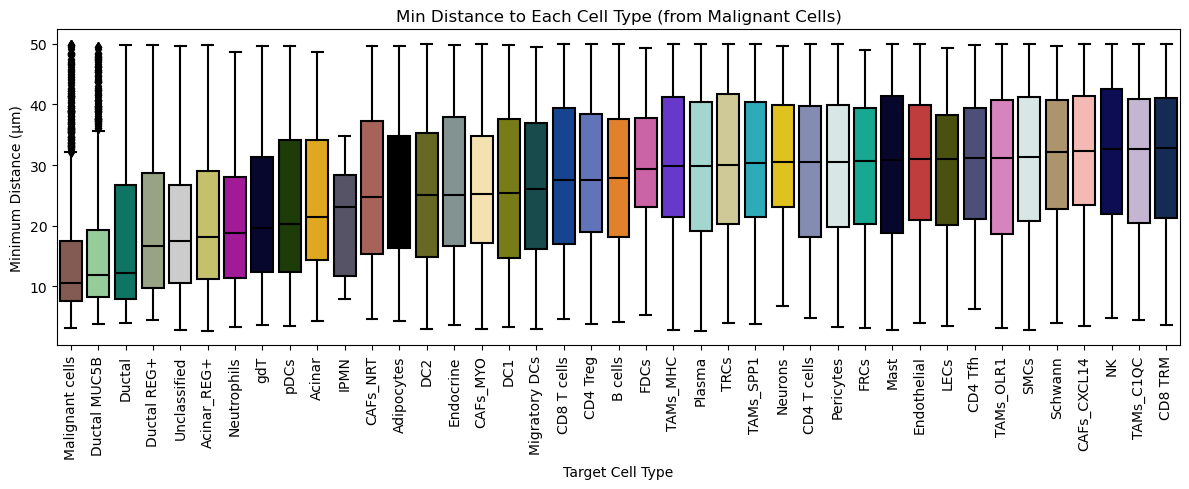

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Compute median min distance per target type
order = (
    proximity_df
    .groupby("Target_cell_type")["Min_Distance_um"]
    .median()
    .sort_values()  # ascending: closest first
    .index
)
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=proximity_df,
    x="Target_cell_type",
    y="Min_Distance_um",
    palette=manual_colors,
    order=order
)
plt.xticks(rotation=90)
plt.title("Min Distance to Each Cell Type (from Malignant Cells)")
plt.ylabel("Minimum Distance (µm)")
plt.xlabel("Target Cell Type")
plt.tight_layout()
plt.show()

In [18]:
focus_labels = ['Malignant cells', 'Ductal MUC5B', 'Ductal', 'Acinar_REG+','Acinar']
# Filter DataFrame
focus_df = proximity_df[proximity_df['Target_cell_type'].isin(focus_labels)].copy()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

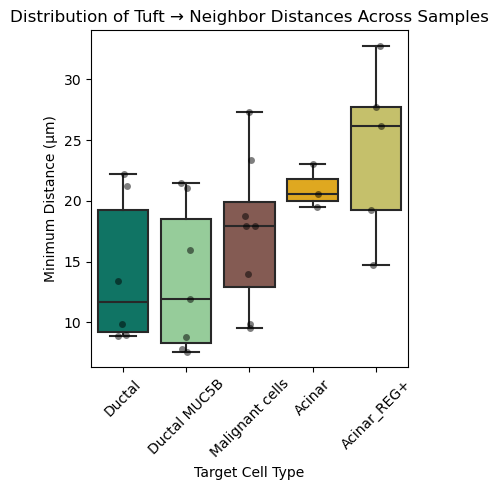

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

median_matrix = (
    focus_df
    .groupby(["Sample", "Target_cell_type"])["Min_Distance_um"]
    .median()
    .unstack()
    .fillna(np.nan)
)

# Melt for plotting
melted = (
    median_matrix
    .reset_index()
    .melt(id_vars="Sample", var_name="Target_cell_type", value_name="Median_Distance_um")
)

# Compute global median for ordering
order = (
    melted.groupby("Target_cell_type")["Median_Distance_um"]
    .median()
    .sort_values()
    .index.tolist()
)

# Define custom colors (match to your labels)
custom_palette = {
    "Malignant cells": '#8c564b',
    "Ductal MUC5B": '#8dd593',
    "Ductal": '#00846f',
    "Acinar":"#ffb500",
    "Acinar_REG+": '#d4cd5c',
    "CD8 T cells": '#023fa5'
}

# Plot with ordering and colors
plt.figure(figsize=(4, 5))
sns.boxplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    palette=custom_palette
)
sns.stripplot(
    data=melted,
    x="Target_cell_type",
    y="Median_Distance_um",
    order=order,
    color='black',
    alpha=0.5
)
plt.title("Distribution of Tuft → Neighbor Distances Across Samples")
plt.ylabel("Minimum Distance (µm)")
plt.xlabel("Target Cell Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
melted = melted.dropna(subset=["Median_Distance_um"])

In [29]:
melted

,Sample,Target_cell_type,Median_Distance_um
0,MH065_314,Acinar,20.524517
3,MH096_480,Acinar,23.039529
4,MH097_314,Acinar,19.496231
8,MH065_314,Acinar_REG+,32.764817
10,MH074_480,Acinar_REG+,14.713024
11,MH096_480,Acinar_REG+,19.231379
12,MH097_314,Acinar_REG+,27.696349
15,MH107_480,Acinar_REG+,26.138767
16,MH065_314,Ductal,9.863563
18,MH074_480,Ductal,21.179141


## Spatial neighbourhood enrichment

In [39]:
adata_dict = {
    "MH065_314":adata_065_314, 
    "MH074_314":adata_074_314, 
    "MH096_314":adata_096_314,
    "MH097_314":adata_097_314,
    "MH099_314":adata_099_314, 
    "MH104_314":adata_104_314, 
    "MH106_314":adata_106_314, 
    "MH107_314":adata_107_314,
    "MH065_480":adata_065_480, 
    "MH074_480":adata_074_480,
    "MH096_480":adata_096_480, 
    "MH097_480":adata_097_480,
    "MH099_480":adata_099_480,
    "MH104_480":adata_104_480, 
    "MH106_480":adata_106_480, 
    "MH107_480":adata_107_480
}
  
z_matrices = {}
for name, ad in adata_dict.items():
    z = ad.uns["cell_class_threshold_nhood_enrichment"]["zscore"]
    labels = ad.obs["cell_class_threshold"].cat.categories
    z_df = pd.DataFrame(z, index=labels, columns=labels)
    z_matrices[name] = z_df
    
# Stack each matrix, add sample name, and combine
z_long_list = []
for name, z_df in z_matrices.items():
    z_long = z_df.stack().reset_index()
    z_long.columns = ["cluster_1", "cluster_2", "zscore"]
    z_long["sample"] = name
    z_long_list.append(z_long)

z_combined = pd.concat(z_long_list, ignore_index=True)

In [40]:
z_tuf = z_combined[z_combined["cluster_1"] == "Tuft"].copy()
z_tuf = z_tuf[z_tuf["cluster_2"] != "Unassigned"].copy()
z_tuf = z_tuf[z_tuf["cluster_2"] != "Unclassified"].copy() # from MH74
from scipy.stats import zscore

# Exclude self-interaction - before doing min-max
z_tuf = z_tuf[z_tuf["cluster_1"] != z_tuf["cluster_2"]]

# Min-max normalization function
def min_max(x):
    return (x - x.min()) / (x.max() - x.min())

# Apply within each sample
z_tuf["zscore_minmax"] = z_tuf.groupby("sample")["zscore"].transform(min_max)

In [41]:
z_tuf

,cluster_1,cluster_2,zscore,sample,zscore_minmax
1088,Tuft,Acinar,4.435651,MH065_314,0.652323
1089,Tuft,Acinar_REG+,2.730493,MH065_314,0.574069
1090,Tuft,B cells,-5.304174,MH065_314,0.205337
1091,Tuft,CAFs_CXCL14,-9.302730,MH065_314,0.021833
1092,Tuft,CAFs_MYO,-9.778460,MH065_314,0.000000
...,...,...,...,...,...
16209,Tuft,TAMs_MHC,-3.037941,MH107_480,0.235290
16210,Tuft,TAMs_OLR1,2.238599,MH107_480,0.344386
16211,Tuft,TAMs_SPP1,1.822288,MH107_480,0.335779
16214,Tuft,gdT,6.706948,MH107_480,0.436773


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


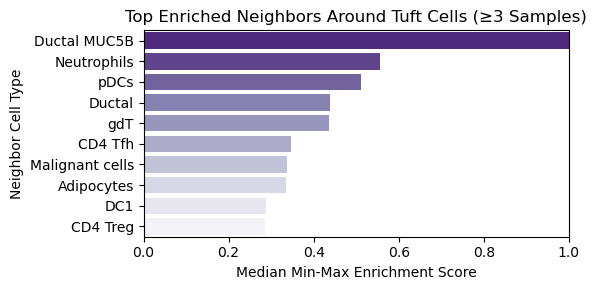

In [42]:
# Calculate median enrichment and number of samples per neighbor
top5_summary = (
    z_tuf.groupby("cluster_2")
    .agg(
        median_score=("zscore_minmax", "median"),   # <-- use median here
        n_samples=("sample", "nunique")
    )
    .reset_index()
)

# Only keep neighbors observed in ≥ 3 samples
top5_summary = top5_summary[top5_summary["n_samples"] >= 3]

# select top 10 based on median enrichment
top5_summary = top5_summary.sort_values("median_score", ascending=False).head(10)

plt.figure(figsize=(6, 3))
ax = sns.barplot(
    data=top5_summary,
    x="median_score", y="cluster_2",
    palette="Purples_r"
)

plt.xlabel("Median Min-Max Enrichment Score")
plt.ylabel("Neighbor Cell Type")
plt.title("Top Enriched Neighbors Around Tuft Cells (≥3 Samples)")
plt.xlim(0, 1.0)
plt.tight_layout()
#plt.savefig("EnrichmentAnalysisTuft_bar.pdf")
plt.show()

### Heterogenous tuft-enriched niche in MH074_314

In [46]:
adata_074_314.obs['cell_class_threshold'].cat.categories

Index(['CAFs_CXCL14', 'CAFs_MYO', 'CAFs_NRT', 'CD4 T cells', 'CD4 Treg',
       'CD8 T cells', 'CD8 TRM', 'DC1', 'DC2', 'Ductal MUC5B', 'Ductal REG+',
       'Endothelial', 'LECs', 'Malignant cells', 'Mast', 'Migratory DCs', 'NK',
       'Pericytes', 'Plasma', 'SMCs', 'Schwann', 'TAMs_C1QC', 'TAMs_MHC',
       'TAMs_OLR1', 'TAMs_SPP1', 'Tuft', 'Unclassified'],
      dtype='object')

In [47]:
tuft_niche = adata_074_314[adata_074_314.obs['cell_class_threshold'].isin(['Ductal MUC5B', 'Ductal REG+','Malignant cells','Tuft','CAFs_CXCL14', 'CAFs_MYO','Endothelial','TAMs_SPP1', 'Schwann'])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:105: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[group]):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:161: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


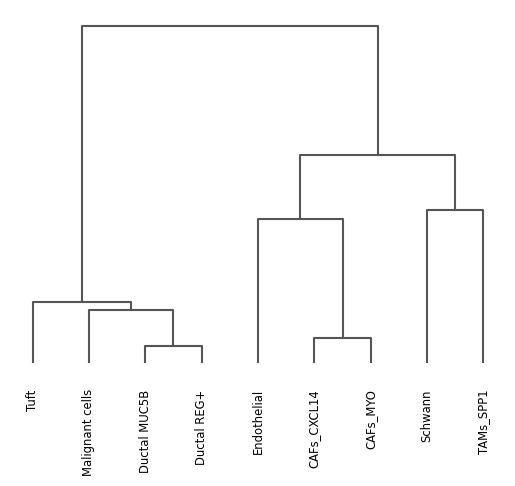

<Axes: >

In [48]:
# Running dendogram
sc.tl.dendrogram(tuft_niche, groupby = "cell_class_threshold")
sc.pl.dendrogram(tuft_niche, groupby = "cell_class_threshold")

In [49]:
# USING THE SAME SET OF GENES in snRNA-seq
genes_anno = ['RGS13','AVIL','POU2F3','BMX',
              'KRT19','KRT8','KRT7','MUC1',
              'SLC4A4','CFTR','REG1A','MUC5B','MUC6',
              'REG3A','REG3G',
              'VWF','PLVAP',
              'CXCL14','COL11A1','POSTN',#'FN1',
              'CHL1','CDH19','NGFR',
              'OLR1',#'HBEGF',
              'SPP1','LIPA','CSTB','MARCO','APOE'
        ]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


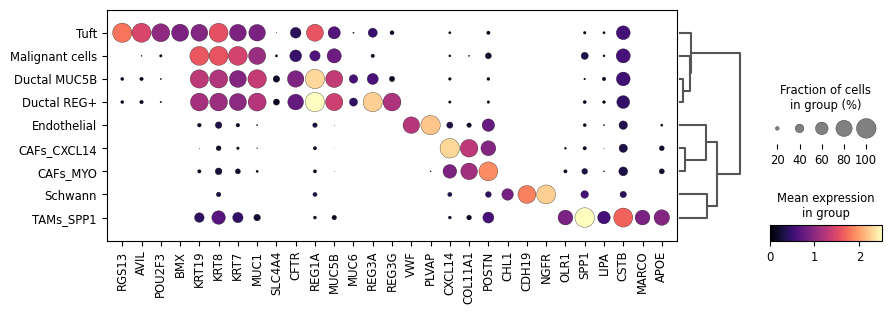

In [50]:
sc.pl.dotplot(tuft_niche, var_names = genes_anno , groupby='cell_class_threshold', #swap_axes = True, 
             figsize=(10, 3), vmax=2.5,vmin = 0, dot_min=0.1, cmap = 'magma', #save="MH074_314_tuft_niche_expression.pdf",
             dendrogram=True)

In [52]:
tuft_niche.uns['cell_class_threshold_colors'] = ['#FFB0A7','#FFE5A7','#8dd593',"#9aa880",'#d62728', '#8c564b','#b79762','#17becf','#9467bd']

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

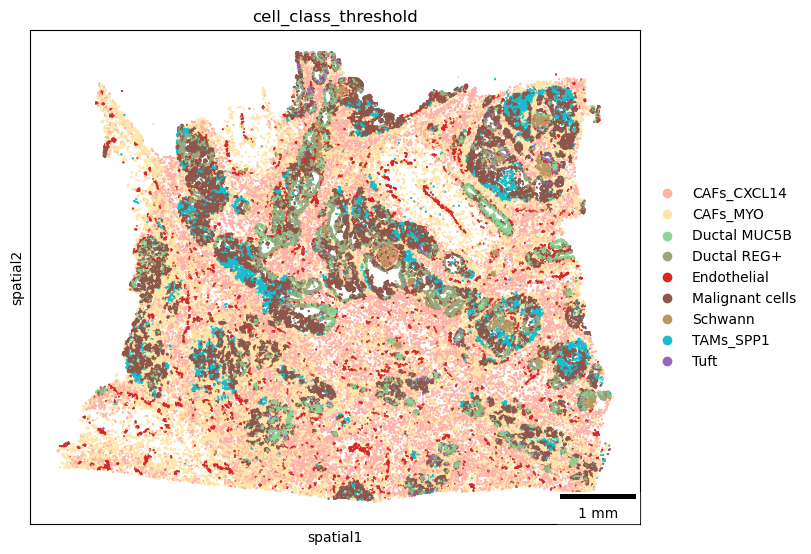

In [57]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    tuft_niche,
    library_id="spatial",
    shape=None,
    color=[
        "cell_class_threshold"
    ],
    wspace=0.4, figsize=(8,8),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    size=1,
    img=False,
    ##save='MH074_314_rep_tuft_niche.pdf'
)

In [54]:
tuft_only = tuft_niche[tuft_niche.obs['cell_class_threshold'].isin(['Tuft'])]

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:26: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map 

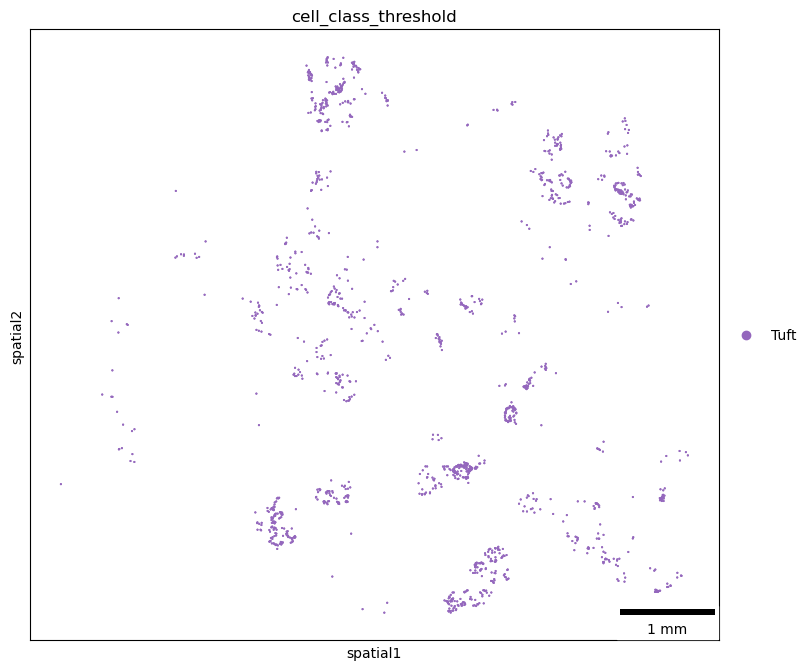

In [53]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    tuft_only,
    library_id="spatial",
    shape=None,
    color=[
        "cell_class_threshold"
    ],
    wspace=0.4, figsize=(8,8),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    size=1,
    img=False,
    save='MH074_314_rep_tuft_only.pdf'
)

# Specific Tuft enriched areas
##### Where selected regions were re-analysed to confirm the identity of Tuft

### 1. Spatial profiling of tuft-containing region in PanIN2 (annotated by pathologist) 

In [3]:
MH096_Tuft_subset = sc.read_h5ad("MH096_ADM_cropped_setseed.h5ad")

In [4]:
epi = MH096_Tuft_subset[MH096_Tuft_subset.obs['predicted_cell_type_threshold'].isin(['Acinar','Acinar_REG+','Ductal', 'Ductal MUC5B','Malignant cells', 'Tuft'])]

In [5]:
epi.uns['predicted_cell_type_threshold_colors']=['#ffb500','#17becf','#00846f','#8dd593','#8c564b','#9467bd']

/tmp/ipykernel_45011/743795583.py:1: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  epi.uns['predicted_cell_type_threshold_colors']=['#ffb500','#17becf','#00846f','#8dd593','#8c564b','#9467bd']


/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

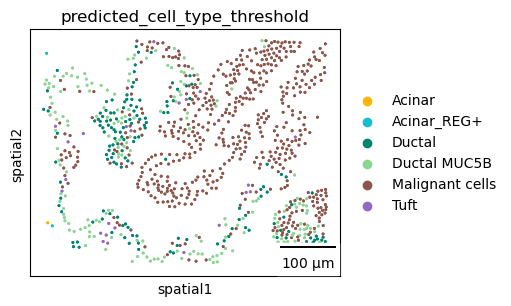

In [8]:
sq.pl.spatial_scatter(
    epi,
    library_id="spatial",
    shape=None,
    color=[
        "predicted_cell_type_threshold"
    ],
    wspace=0.4, figsize=(5,5),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    size=5,
    img=False,
    crop_coord=(5400,1400,5900,1800), #left, right, top, bottom,
    save='MH096_480_rep_tuft_niche.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


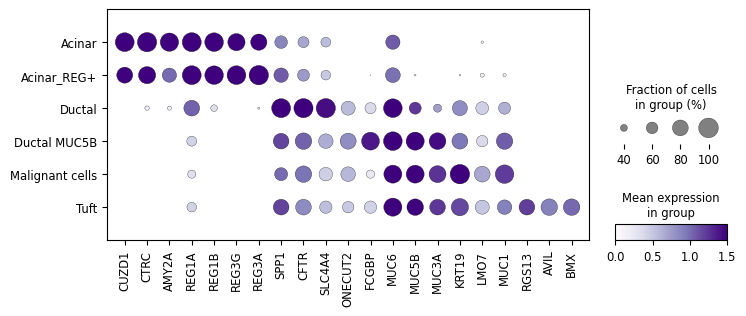

In [11]:
adm_markers= ['CUZD1','CTRC','AMY2A','REG1A','REG1B','REG3G','REG3A','SPP1',
              'CFTR','SLC4A4','ONECUT2','FCGBP','MUC6','MUC5B','MUC3A','KRT19','LMO7','MUC1','RGS13','AVIL','BMX']

order = ['Acinar', 'Acinar_REG+', 
                 'Ductal', 'Ductal MUC5B', 'Malignant cells', 'Tuft']
epi.obs['predicted_cell_type_threshold'] = epi.obs['predicted_cell_type_threshold'].cat.reorder_categories(
    order, ordered=True
)

sc.pl.dotplot(epi, var_names = adm_markers , groupby='predicted_cell_type_threshold', #swap_axes = True, 
             figsize=(8, 3), vmax=1.5, vmin = 0, dot_min=0.2, cmap = 'Purples', 
             dendrogram=False)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

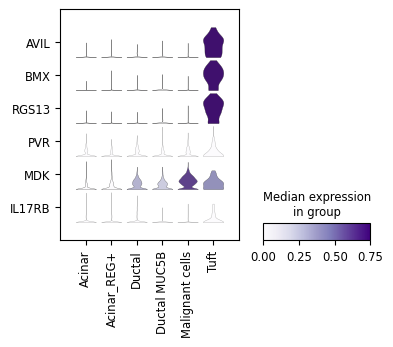

In [21]:
marker_genes_dict = ['AVIL','BMX','RGS13','PVR','MDK','IL17RB']

sc.pl.stacked_violin(
    epi, marker_genes_dict, groupby="predicted_cell_type_threshold", swap_axes=True, dendrogram=False, figsize=(4, 3),
    cmap = 'Purples', vmax=0.75,
    #save='MH096_PVR_tuftexpression.pdf'
)

### 2. AVIL+ cells in well-differentiated carcinoma glands

In [17]:
MH099_Tuft_subset = sc.read_h5ad("_MH099_ADM_cropped_highmag_ss_Dec25.h5ad") 

In [18]:
MH099_Tuft_subset

AnnData object with n_obs × n_vars = 827 × 458
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_1.0', 'leiden_2.0', 'leiden_2.5', 'leiden_3.0', 'anno', 'predicted_cell_type_threshold', 'Malignant cells_score', 'Ductal MUC5B_score', 'Tuft_score', 'Endothelial_score', 'Pericytes_score', 'CAFs_MYO_score', 'Neutrophils_score', 'TAMs_SPP1_score', 'TAMs_OLR1_score', 'max_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_c

In [19]:
MH099_Tuft_subset.obs['predicted_cell_type_threshold'].cat.categories

Index(['CAFs_MYO', 'Ductal MUC5B', 'Endothelial', 'Malignant cells',
       'Neutrophils', 'Pericytes', 'TAMs_OLR1', 'TAMs_SPP1', 'Tuft'],
      dtype='object')

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

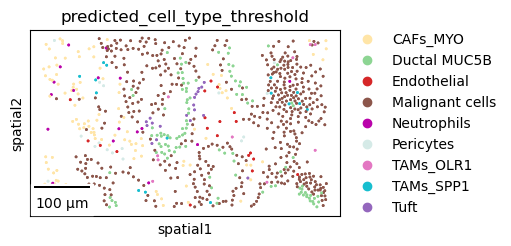

In [24]:
# Spatial distribution of cells
MH099_Tuft_subset.uns['predicted_cell_type_threshold_colors']=['#FFE5A7','#8dd593','#d62728','#8c564b','#b903aa','#d5eae7',
                                            #'#c5b0d5',"#5E21E3",
                                            '#e377c2','#17becf','#9467bd']

sq.pl.spatial_scatter(
    MH099_Tuft_subset, shape=None, color=['predicted_cell_type_threshold'], size=4, library_id="spatial", figsize=(5, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower left"},
    save='MH099_480_rep_tuft_niche.pdf')

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_color_utils.py:26: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map 

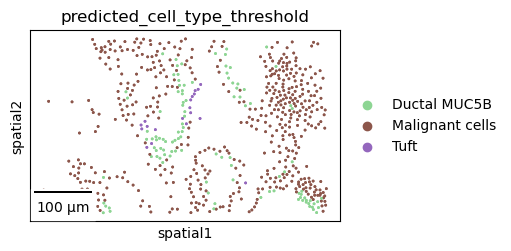

In [29]:
sq.pl.spatial_scatter(
    epi_v2, shape=None, color=['predicted_cell_type_threshold'], size=4, library_id="spatial", figsize=(5, 3),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower left"},
    save='MH099_480_rep_tuft_niche.pdf')

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype 

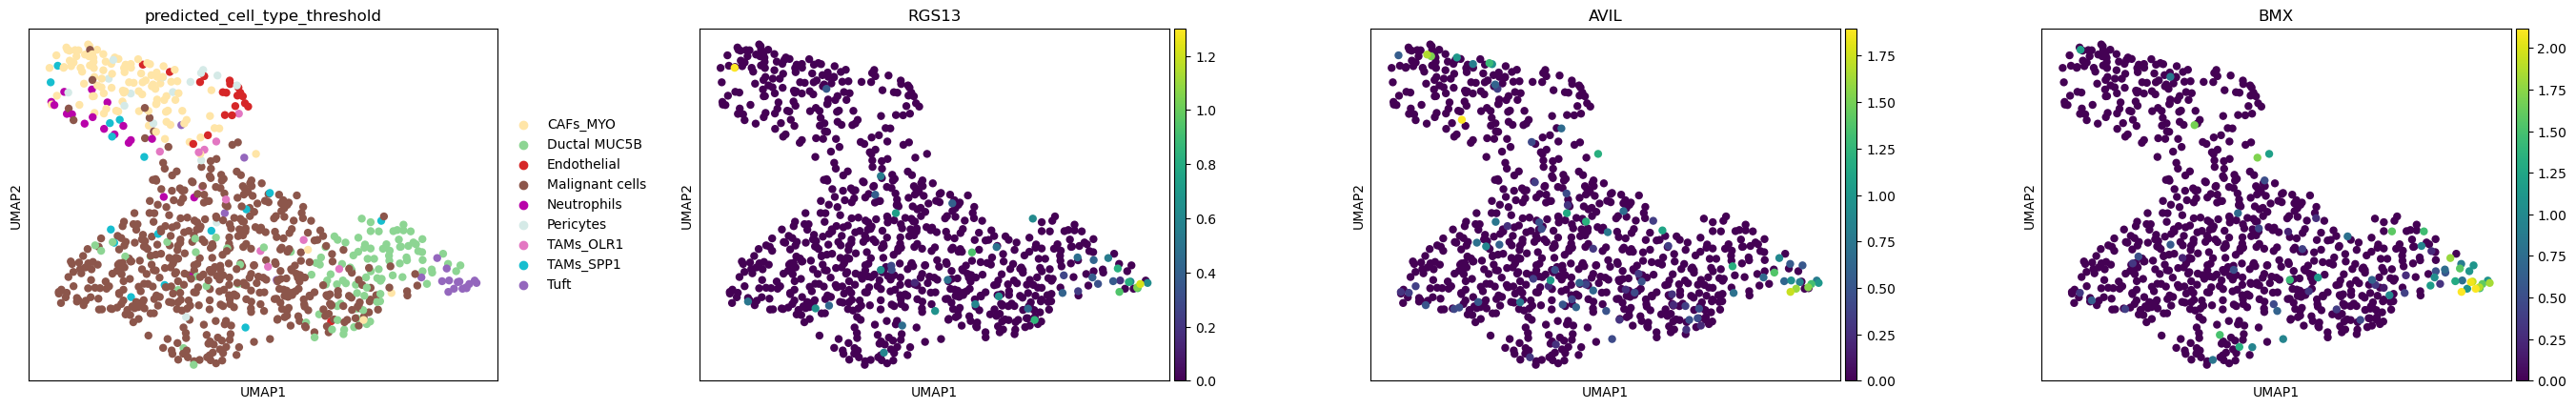

In [31]:
sc.pl.umap(MH099_Tuft_subset, color=["predicted_cell_type_threshold","RGS13",'AVIL','BMX'], wspace=0.3, 
          save='MH099_480_rep_tuft_niche_umap.pdf')

In [26]:
epi_v2 = MH099_Tuft_subset[MH099_Tuft_subset.obs['predicted_cell_type_threshold'].isin(['Ductal MUC5B','Malignant cells','Tuft'])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

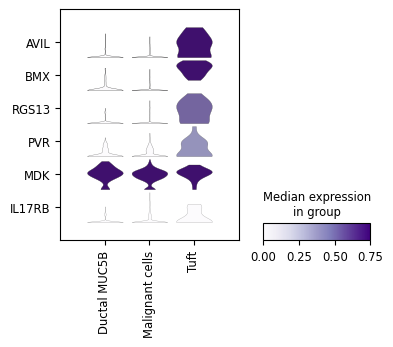

In [28]:
marker_genes_dict = ['AVIL','BMX','RGS13','PVR','MDK','IL17RB']

sc.pl.stacked_violin(
    epi_v2, marker_genes_dict, groupby="predicted_cell_type_threshold", swap_axes=True, dendrogram=False, figsize=(4, 3),vmax=0.75,
    cmap = 'Purples',
    save='MH099_PVR_tuftexpression.pdf'
)

### 3. Tuft cells associated with PanIN and not with IPMN

In [30]:
new_directory = "/homevol/huemail/G000428_MaiLa/Xenium_repeated_n8_probev2/Tuft"
os.chdir(new_directory)

In [31]:
MH106_Tuft_subset = sc.read_h5ad("MH106_ADM_PDAC_highmag_ss.h5ad")

In [44]:
MH106_Tuft_subset.uns['predicted_cell_type_threshold_colors']=['#FFB0A7','#FFE5A7',"#B4584D",'#7d87b9','#023fa5',"#888D07","#717417", '#8dd593',
                                                          '#d62728', "#525068",  '#8c564b','#b903aa',#'#000035',
                                                          "#00025E",'#b79762','#9cded6','#c5b0d5',"#5E21E3",'#e377c2',"#442883",'#d5eae7']

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

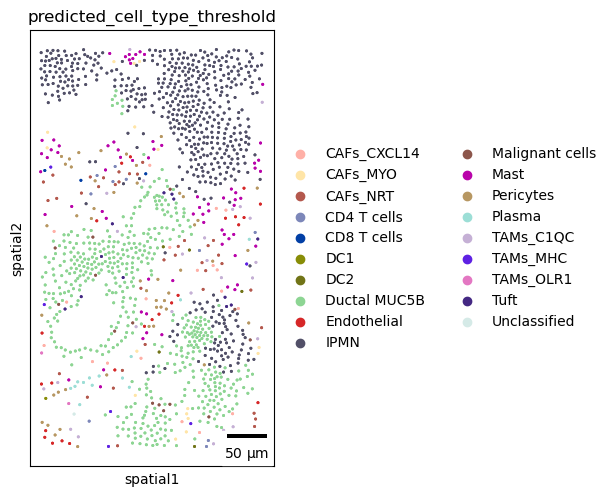

In [47]:
sq.pl.spatial_scatter(
    MH106_Tuft_subset,
    library_id="spatial",
    shape=None,
    color=["predicted_cell_type_threshold"],
    wspace=0.4, figsize=(6,6),
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    size=5,
    img=False,
    crop_coord=(8220,3700,8500,4200), #left, right, top, bottom,
    #save='MH074_314_rep_tuft_niche.pdf'
)

In [48]:
epi_v3 = MH106_Tuft_subset[MH106_Tuft_subset.obs['predicted_cell_type_threshold'].isin(['Ductal MUC5B','Malignant cells','Tuft','IPMN'])]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

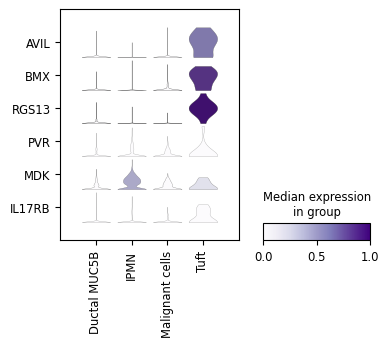

In [51]:
sc.pl.stacked_violin(
    epi_v3, marker_genes_dict, groupby="predicted_cell_type_threshold", swap_axes=True, dendrogram=False, figsize=(4, 3),vmax=1,
    cmap = 'Purples')